In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('Tweets.csv')
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
df.shape

(27481, 4)

In [5]:
df.columns.to_list()

['textID', 'text', 'selected_text', 'sentiment']

In [6]:
df['sentiment'].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [7]:
df=df[['text','sentiment']]

In [8]:
df.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [9]:
df.isnull().sum()

text         1
sentiment    0
dtype: int64

In [10]:
df=df.dropna()
df=df.reset_index(drop=True)
print("New shape:",df.shape)
print("Missing values:",df.isnull().sum().sum())

New shape: (27480, 2)
Missing values: 0


In [11]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK data downloaded!")

NLTK data downloaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Adrija\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Adrija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [12]:
import re
from nltk.corpus import stopwords

In [13]:
stop_words=set(stopwords.words('english'))

In [14]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'http\S+','',text)
    text=re.sub(r'[^a-zA-Z\s]','',text)
    text=text.strip()
    words=text.split()
    words=[w for w in words if w not in stop_words]
    return ' '.join(words)

In [15]:
df['cleaned_text']=df['text'].apply(clean_text)
print("Text cleaned!")
print("\nOriginal:",df['text'][1])
print("Cleaned:",df['cleaned_text'][1])

Text cleaned!

Original:  Sooo SAD I will miss you here in San Diego!!!
Cleaned: sooo sad miss san diego


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
X=df['cleaned_text']
y=df['sentiment']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
tfidf=TfidfVectorizer(max_features=5000)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)
print("Data split successfully!")
print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])
print("Features (words):",X_train_tfidf.shape[1])

Data split successfully!
Training samples: 21984
Testing samples: 5496
Features (words): 5000


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf,y_train)
print("Model trained successfully!")

Model trained successfully!


In [21]:
from sklearn.metrics import accuracy_score, classification_report

In [22]:
y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Detailed Report:")
print(classification_report(y_test,y_pred))

Accuracy: 68.70%
Detailed Report:
              precision    recall  f1-score   support

    negative       0.71      0.57      0.63      1572
     neutral       0.63      0.75      0.68      2236
    positive       0.77      0.71      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



In [23]:
def predict_sentiment(tweet):
    cleaned=clean_text(tweet)
    vectorized=tfidf.transform([cleaned])
    prediction=model.predict(vectorized)
    return prediction[0]

print(predict_sentiment("I love this so much!"))
print(predict_sentiment("This is the worst day ever"))
print(predict_sentiment("I went to the store today"))

positive
negative
neutral


In [24]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000,C=5,solver='lbfgs')
model.fit(X_train_tfidf,y_train)
y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f"Improved Accuracy: {accuracy * 100:.2f}%")

Improved Accuracy: 67.12%


In [25]:
from sklearn.svm import LinearSVC

model=LinearSVC(max_iter=1000)
model.fit(X_train_tfidf,y_train)
y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

SVM Accuracy: 67.29%


In [26]:
from sklearn.naive_bayes import MultinomialNB

model=MultinomialNB()
model.fit(X_train_tfidf,y_train)
y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f"Naive Bayes Accuracy: {accuracy * 100:.2f}%")

Naive Bayes Accuracy: 63.83%


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [28]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf,y_train)
y_pred=model.predict(X_test_tfidf)

Text(0.5, 36.72222222222221, 'Predicted')

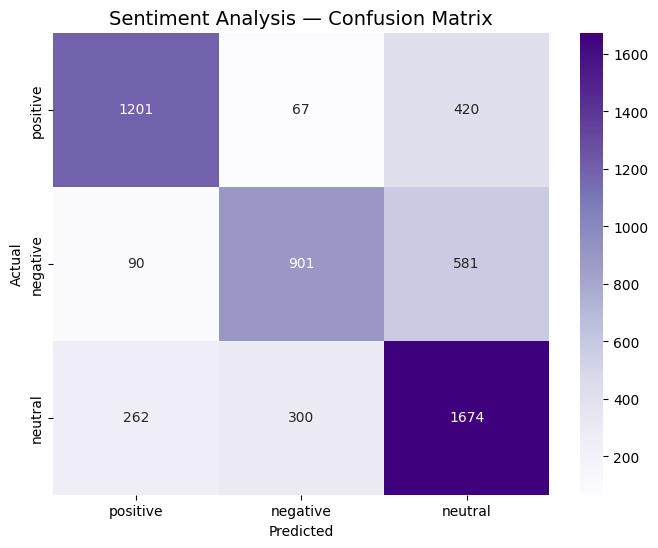

In [29]:
cm=confusion_matrix(y_test, y_pred, labels=['positive','negative','neutral'])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True,fmt='d',cmap='Purples',xticklabels=['positive','negative','neutral'],yticklabels=['positive','negative','neutral'])
plt.title('Sentiment Analysis — Confusion Matrix',fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')

(array([0, 1, 2]),
 [Text(0, 0, 'neutral'), Text(1, 0, 'positive'), Text(2, 0, 'negative')])

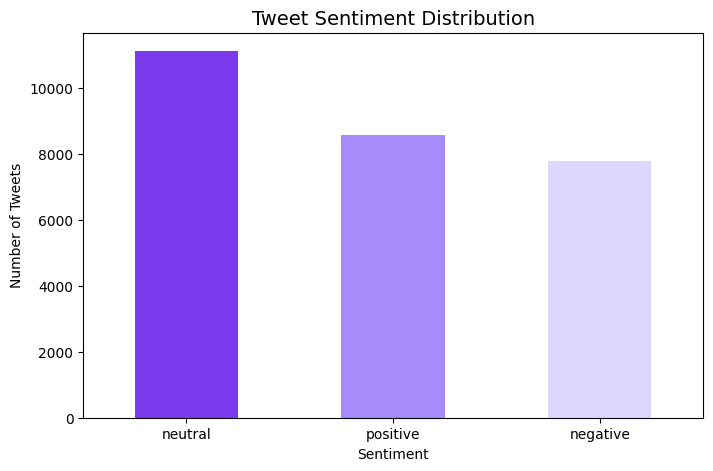

In [31]:
plt.figure(figsize=(8,5))
df['sentiment'].value_counts().plot(kind='bar',color=['#7c3aed','#a78bfa','#ddd6fe'])
plt.title('Tweet Sentiment Distribution',fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

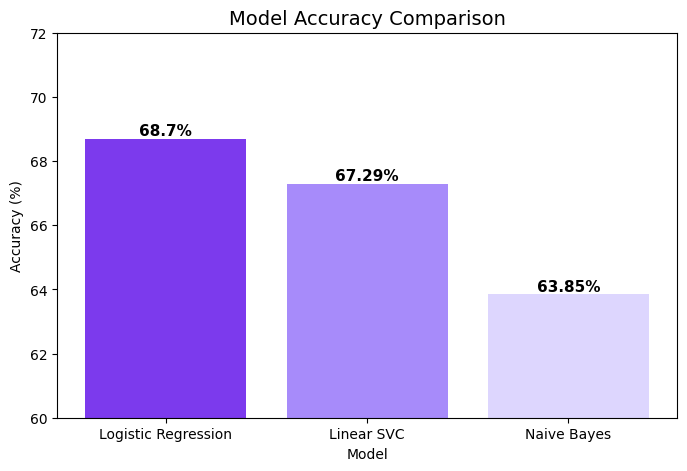

In [33]:
models=['Logistic Regression','Linear SVC','Naive Bayes']
accuracies=[68.70,67.29,63.85]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies,color=['#7c3aed','#a78bfa','#ddd6fe'])
plt.title('Model Accuracy Comparison',fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(60,72)
for bar,acc in zip(bars,accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, 
             bar.get_height()+0.1, 
             f'{acc}%',ha='center',fontsize=11,fontweight='bold')

In [34]:
def predict_sentiment(tweet):
    cleaned=clean_text(tweet)
    vectorized=tfidf.transform([cleaned])
    prediction=model.predict(vectorized)
    return prediction[0]

test_tweets=[
    "I love this movie so much!",
    "This is the worst experience ever",
    "I went to the market today",
    "So happy to see my friends again!",
    "I hate Mondays",
    "The weather is okay today"
]

for tweet in test_tweets:
    sentiment=predict_sentiment(tweet)
    print(f"{sentiment.upper()} --> {tweet}")

POSITIVE --> I love this movie so much!
NEGATIVE --> This is the worst experience ever
NEUTRAL --> I went to the market today
POSITIVE --> So happy to see my friends again!
NEGATIVE --> I hate Mondays
NEUTRAL --> The weather is okay today


# Sentiment Analysis of Tweets
### AI & ML Lab Project | 2026

---

## Problem Statement
Social media generates millions of opinions every day. 
Manually reading and classifying tweets is impossible at scale.
This project builds an NLP model that automatically detects 
whether a tweet is **Positive**, **Negative**, or **Neutral**.

---

## Dataset
- **Source:** Kaggle — Twitter Tweets Sentiment Dataset
- **Size:** 27,480 tweets
- **Labels:** Positive, Negative, Neutral
- **Columns used:** `text`, `sentiment`

---

## Approach
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Feature Extraction using TF-IDF
4. Model Training & Comparison
5. Evaluation & Visualization

---

## Models Compared
| Model | Accuracy |
|-------|----------|
| Logistic Regression | **68.70%** |
| Linear SVC | 67.29% |
| Naive Bayes | 63.85% |

---

## Key Insights
- **Logistic Regression** performed best overall
- The model struggles most with **Neutral** tweets — they sit between positive and negative making them genuinely hard to classify
- **Positive** sentiment had the highest precision (77%) — the model is most confident identifying happy tweets
- **Negative** sentiment had the lowest recall (57%) — some negative tweets were misclassified as neutral
- Even humans disagree on neutral vs mildly positive/negative — 68.7% is a strong result for Twitter data

---

## Technologies Used
- **Python** — core language
- **pandas** — data loading and cleaning
- **NLTK** — text preprocessing and stopword removal
- **scikit-learn** — TF-IDF vectorization and ML models
- **matplotlib & seaborn** — visualizations

---

## Conclusions

- A simple **Logistic Regression** model with TF-IDF features can classify 
tweet sentiment with **68.7% accuracy** — competitive with many complex models
- **Text preprocessing** (removing stopwords, URLs, punctuation) was critical 
— without it accuracy dropped significantly
- The **neutral class is the hardest** to predict — this is a known challenge 
in sentiment analysis even for state-of-the-art models
- **TF-IDF with 5000 features** gave the best balance between speed and accuracy

---

## Limitations & Future Work
- Model doesn't understand **sarcasm** — "Oh great, another Monday" would be 
classified as positive
- Could improve with **deep learning** models like BERT or transformers
- Could expand to **real-time Twitter API** data for live sentiment tracking
- Adding **emojis** as features could improve accuracy significantly

---

## References
- Dataset: [Kaggle Twitter Tweets Sentiment Dataset](https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset)
- scikit-learn Documentation
- NLTK Documentation